In [19]:
# Histogram of track lifetimes

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sys 
import os
import seaborn as sns
import matplotlib.ticker as ticker
import zarr 
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import numpy as np
from matplotlib.colors import LinearSegmentedColormap

pythonPackagePath = os.path.abspath('/Users/valerie/LLSM-CME-ANALYSIS/Final/src')
sys.path.append(pythonPackagePath)

from intensity_time_plots import filter_track_ids_by_length_ranges, random_track_ids
from intensity_time_plots import intensity_time_plot, createBufferForLifetimeCohort, intensity_time_plot_onetrack
from intensity_time_plots import createBufferForLifetimeCohort_normalized, cumulative_plots, cumulative_plots_ax


%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [21]:
# Change this variable to where your python packages are. Don't remove the r
package_dir = r'/Users/valerie/LLSM-CME-ANALYSIS/Final/src'

# Define the file directories (change these to reflect your directories)
base_dir =  r'/Volumes/ActiveNAS/Valerie/TransferFolder/'
input_file_directory = '20251204_DetectionTesting/lumenoids_analysis/'
zarr_file_directory = input_file_directory + 'zarr_file/all_channels_data'

zarr_full_path = os.path.join(base_dir, zarr_file_directory)

# input_directory_all_tracks_full = os.path.join(base_dir, input_file_directory) + 'datasets/track_df_cleaned_final_full.pkl'
input_directory_all_tracks_full = os.path.join(base_dir, input_file_directory) + 'datasets/edge_filtered_tracks_final.pkl'



input_directory_tracks = 'datasets'
#input_directory_filtered = 'filtered_tracks_final.pkl'
input_directory_filtered = 'peak_filtered_tracks_final.pkl'
input_directory_full_filtered_tracks = (os.path.join(base_dir, input_file_directory, 
                                                    input_directory_tracks, input_directory_filtered))

In [22]:
track_df = pd.read_pickle(input_directory_all_tracks_full)
filtered_tracks = pd.read_pickle(input_directory_full_filtered_tracks)
z2 = zarr.open(zarr_full_path, mode='r')

In [23]:
# Number of frames in the dataset, important for plotting montages later on
max_frames = z2.shape[0]
print(f'Number of frames in the dataset: {max_frames}')

Number of frames in the dataset: 150


In [27]:
#Print size of track_df and filtered_tracks
print("Size of track_df:", track_df.shape)
print("Size of filtered_tracks:", filtered_tracks.shape)


Size of track_df: (1234, 32)
Size of filtered_tracks: (423, 32)


Dataset Summary:
Total tracks: 423
Channel2+ tracks: 285 (67.4%)
Channel2- tracks: 138 (32.6%)


/var/folders/0s/t8g59tpd7yv290krn_d3fn1h0000gp/T/ipykernel_3052/3886964880.py:53: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax3.boxplot(box_data, labels=['DNM2+', 'DNM2-'],


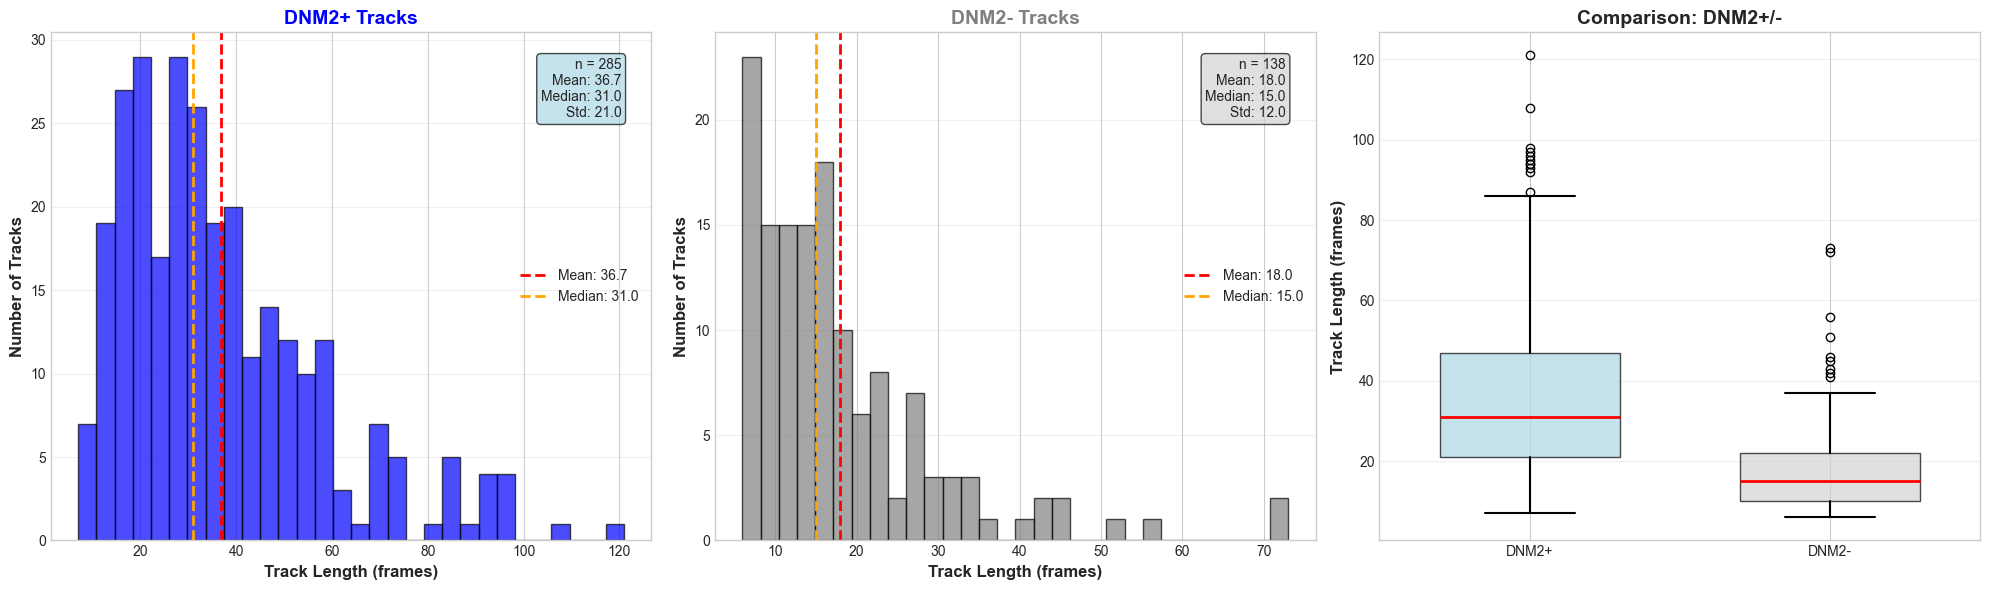


STATISTICAL COMPARISON
Channel2+ tracks: Mean = 36.74, Median = 31.00
Channel2- tracks: Mean = 18.01, Median = 15.00
Difference in means: 18.73 frames

T-test p-value: 0.0000
Mann-Whitney U test p-value: 0.0000

✓ SIGNIFICANT: Track lengths differ between Channel2+ and Channel2- (p < 0.05)


In [109]:
# Separate tracks by channel2_positive status
channel2_positive_tracks = filtered_tracks[filtered_tracks['channel2_positive'] == True]
channel2_negative_tracks = filtered_tracks[filtered_tracks['channel2_positive'] == False]

print("Dataset Summary:")
print(f"Total tracks: {len(filtered_tracks)}")
print(f"Channel2+ tracks: {len(channel2_positive_tracks)} ({len(channel2_positive_tracks)/len(filtered_tracks)*100:.1f}%)")
print(f"Channel2- tracks: {len(channel2_negative_tracks)} ({len(channel2_negative_tracks)/len(filtered_tracks)*100:.1f}%)")

# Create three subplots
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(20, 6))

# Channel2 Positive histogram
ax1.hist(channel2_positive_tracks['track_length'], bins=30, color='blue', alpha=0.7, edgecolor='black')
ax1.set_xlabel('Track Length (frames)', fontsize=12, fontweight='bold')
ax1.set_ylabel('Number of Tracks', fontsize=12, fontweight='bold')
ax1.set_title('DNM2+ Tracks', fontsize=14, fontweight='bold', color='blue')
ax1.grid(axis='y', alpha=0.3)

# Stats for channel2+
mean_pos = channel2_positive_tracks['track_length'].mean()
median_pos = channel2_positive_tracks['track_length'].median()
ax1.axvline(mean_pos, color='red', linestyle='--', linewidth=2, label=f'Mean: {mean_pos:.1f}')
ax1.axvline(median_pos, color='orange', linestyle='--', linewidth=2, label=f'Median: {median_pos:.1f}')
ax1.legend()

stats_text_pos = f"n = {len(channel2_positive_tracks)}\nMean: {mean_pos:.1f}\nMedian: {median_pos:.1f}\nStd: {channel2_positive_tracks['track_length'].std():.1f}"
ax1.text(0.95, 0.95, stats_text_pos, transform=ax1.transAxes,
         fontsize=10, verticalalignment='top', horizontalalignment='right',
         bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.7))

# Channel2 Negative histogram
ax2.hist(channel2_negative_tracks['track_length'], bins=30, color='gray', alpha=0.7, edgecolor='black')
ax2.set_xlabel('Track Length (frames)', fontsize=12, fontweight='bold')
ax2.set_ylabel('Number of Tracks', fontsize=12, fontweight='bold')
ax2.set_title('DNM2- Tracks', fontsize=14, fontweight='bold', color='gray')
ax2.grid(axis='y', alpha=0.3)

# Stats for channel2-
mean_neg = channel2_negative_tracks['track_length'].mean()
median_neg = channel2_negative_tracks['track_length'].median()
ax2.axvline(mean_neg, color='red', linestyle='--', linewidth=2, label=f'Mean: {mean_neg:.1f}')
ax2.axvline(median_neg, color='orange', linestyle='--', linewidth=2, label=f'Median: {median_neg:.1f}')
ax2.legend()

stats_text_neg = f"n = {len(channel2_negative_tracks)}\nMean: {mean_neg:.1f}\nMedian: {median_neg:.1f}\nStd: {channel2_negative_tracks['track_length'].std():.1f}"
ax2.text(0.95, 0.95, stats_text_neg, transform=ax2.transAxes,
         fontsize=10, verticalalignment='top', horizontalalignment='right',
         bbox=dict(boxstyle='round', facecolor='lightgray', alpha=0.7))

# Boxplot comparison
box_data = [channel2_positive_tracks['track_length'], channel2_negative_tracks['track_length']]
bp = ax3.boxplot(box_data, labels=['DNM2+', 'DNM2-'], 
                  patch_artist=True, widths=0.6,
                  medianprops=dict(color='red', linewidth=2),
                  boxprops=dict(facecolor='lightblue', alpha=0.7),
                  whiskerprops=dict(linewidth=1.5),
                  capprops=dict(linewidth=1.5))

# Color the boxes differently
bp['boxes'][0].set_facecolor('lightblue')
bp['boxes'][1].set_facecolor('lightgray')

ax3.set_ylabel('Track Length (frames)', fontsize=12, fontweight='bold')
ax3.set_title('Comparison: DNM2+/-', fontsize=14, fontweight='bold')
ax3.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# Statistical test
from scipy.stats import mannwhitneyu, ttest_ind

# Perform statistical tests
t_stat, p_val_t = ttest_ind(channel2_positive_tracks['track_length'], channel2_negative_tracks['track_length'])
u_stat, p_val_u = mannwhitneyu(channel2_positive_tracks['track_length'], channel2_negative_tracks['track_length'])

print("\n" + "="*60)
print("STATISTICAL COMPARISON")
print("="*60)
print(f"Channel2+ tracks: Mean = {mean_pos:.2f}, Median = {median_pos:.2f}")
print(f"Channel2- tracks: Mean = {mean_neg:.2f}, Median = {median_neg:.2f}")
print(f"Difference in means: {mean_pos - mean_neg:.2f} frames")
print(f"\nT-test p-value: {p_val_t:.4f}")
print(f"Mann-Whitney U test p-value: {p_val_u:.4f}")

if p_val_u < 0.05:
    print("\n✓ SIGNIFICANT: Track lengths differ between Channel2+ and Channel2- (p < 0.05)")
else:
    print("\n✗ NOT SIGNIFICANT: No significant difference in track lengths (p >= 0.05)")
print("="*60)

In [110]:
import random

# Get track IDs for each group
channel2_pos_track_ids = channel2_positive_tracks['track_id'].unique()
channel2_neg_track_ids = channel2_negative_tracks['track_id'].unique()

# Randomly sample 3 from each
random_pos_tracks = random.sample(list(channel2_pos_track_ids), min(3, len(channel2_pos_track_ids)))
random_neg_tracks = random.sample(list(channel2_neg_track_ids), min(3, len(channel2_neg_track_ids)))

print("="*60)
print("RANDOM TRACK IDs FOR SPOT-CHECKING")
print("="*60)

print("\nChannel2+ Tracks (should have DNM2 signal):")
for i, track_id in enumerate(random_pos_tracks, 1):
    track_data = filtered_tracks[filtered_tracks['track_id'] == track_id].iloc[0]
    print(f"  {i}. Track ID: {track_id}")
    print(f"     - Track length: {track_data['track_length']} frames")
    if 'c2_voxel_sum_adjusted_peak' in filtered_tracks.columns:
        print(f"     - C2 peak intensity: {track_data['c2_voxel_sum_adjusted_peak']:.1f}")

print("\nChannel2- Tracks (should NOT have DNM2 signal):")
for i, track_id in enumerate(random_neg_tracks, 1):
    track_data = filtered_tracks[filtered_tracks['track_id'] == track_id].iloc[0]
    print(f"  {i}. Track ID: {track_id}")
    print(f"     - Track length: {track_data['track_length']} frames")
    if 'c2_voxel_sum_adjusted_peak' in filtered_tracks.columns:
        print(f"     - C2 peak intensity: {track_data['c2_voxel_sum_adjusted_peak']:.1f}")

print("="*60)



RANDOM TRACK IDs FOR SPOT-CHECKING

Channel2+ Tracks (should have DNM2 signal):
  1. Track ID: 2746
     - Track length: 20 frames
     - C2 peak intensity: 535.0
  2. Track ID: 2115
     - Track length: 44 frames
     - C2 peak intensity: 1715.8
  3. Track ID: 2389
     - Track length: 47 frames
     - C2 peak intensity: 1004.6

Channel2- Tracks (should NOT have DNM2 signal):
  1. Track ID: 1141
     - Track length: 12 frames
     - C2 peak intensity: 1505.6
  2. Track ID: 1085
     - Track length: 15 frames
     - C2 peak intensity: 1383.8
  3. Track ID: 1982
     - Track length: 15 frames
     - C2 peak intensity: 2242.4


In [5]:
channels_to_plot = [True, True]
triple_positive = filtered_tracks[(filtered_tracks['channel1_positive'] == channels_to_plot[0]) & (filtered_tracks['channel2_positive'] == channels_to_plot[1])]
dynamin_negative_arpc3_negative = filtered_tracks[(filtered_tracks['channel1_positive'] == False) & 
                                                  (filtered_tracks['channel2_positive'] == False)]
low_ARPC3 = triple_positive[(triple_positive['c1_adjusted_voxel_sum_peak'] > 2500) & 
                           (triple_positive['c1_adjusted_voxel_sum_peak'] < 4000)]
high_ARPC3 = triple_positive[(triple_positive['c1_adjusted_voxel_sum_peak'] > 4000)]
# low_ARPC3['track_id']
# high_ARPC3['track_id']
#Conver dynamin positive ARPC3 negative tracks to a list
dn_an = dynamin_negative_arpc3_negative['track_id'].tolist()
# dn_an[333]

KeyError: 'c1_adjusted_voxel_sum_peak'

In [8]:
high_ARPC3[high_ARPC3['membrane_region'] == 'Basal']['track_id']

NameError: name 'high_ARPC3' is not defined

In [140]:
ID = 1982
# triple_positive[triple_positive['track_id'] == ID]['C1_adjusted_voxel_sum_peak']

In [121]:
# track_df[track_df['track_id'] == ID][['frame', 'c2_voxel_sum_adjusted', 'mu_x', 'mu_y', 'mu_z']]

In [122]:
# import pandas as pd
# import matplotlib.pyplot as plt
# from mpl_toolkits.mplot3d import Axes3D
# import numpy as np
# from matplotlib.colors import LinearSegmentedColormap

# def plot_track_3d(df, track_id):
#     """
#     Plot the 3D position of a specific track over time.
    
#     Parameters:
#     df (pandas.DataFrame): DataFrame containing track data with multiple time points
#     track_id (int): The track_id to plot
#     """
#     # Filter data for the specific track
#     track_data = df[df['track_id'] == track_id].copy()
    
#     if track_data.empty:
#         print(f"No data found for track_id {track_id}")
#         return
    
#     # Get the position data - assuming these are arrays stored in a single row
#     x = track_data['mu_x'].values[0]
#     y = track_data['mu_y'].values[0]
#     z = track_data['mu_z'].values[0]
    
#     # Convert to numpy arrays if they aren't already
#     if not isinstance(x, np.ndarray):
#         x = np.array(x)
#     if not isinstance(y, np.ndarray):
#         y = np.array(y)
#     if not isinstance(z, np.ndarray):
#         z = np.array(z)
    
#     # Create time points
#     time_points = np.arange(len(x))
    
#     # Create the 3D plot
#     fig = plt.figure(figsize=(15, 12))
#     ax = fig.add_subplot(111, projection='3d')
    
#     # Plot the trajectory with color gradient representing time
#     scatter = ax.scatter(x, y, z, c=time_points, cmap='viridis', s=50, alpha=0.6)
    
#     # Plot the line connecting points
#     ax.plot(x, y, z, 'b-', alpha=0.3)
    
#     # Mark start and end points
#     ax.scatter(x[0], y[0], z[0], color='green', s=100, marker='o', label='Start')
#     ax.scatter(x[-1], y[-1], z[-1], color='red', s=100, marker='s', label='End')
    
#     # Calculate axis ranges for equal scaling
#     x_range = [x.min(), x.max()]
#     y_range = [y.min(), y.max()]
#     z_range = [z.min(), z.max()]
    
#     # Find the maximum range
#     max_range = max(x_range[1] - x_range[0], 
#                     y_range[1] - y_range[0], 
#                     z_range[1] - z_range[0])
    
#     # Calculate centers
#     x_center = (x_range[1] + x_range[0]) / 2
#     y_center = (y_range[1] + y_range[0]) / 2
#     z_center = (z_range[1] + z_range[0]) / 2
    
#     # Set equal aspect ratio
#     ax.set_xlim([x_center - max_range/2, x_center + max_range/2])
#     ax.set_ylim([y_center - max_range/2, y_center + max_range/2])
#     ax.set_zlim([z_center - max_range/2, z_center + max_range/2])
    
#     # # Add colorbar for time
#     # cbar = plt.colorbar(scatter, ax=ax, pad=0.1)
#     # cbar.set_label('Time Step', rotation=270, labelpad=15, fontweight='bold')

#     # Set labels and title with bold formatting
#     ax.set_xlabel('X Position (voxels)', fontweight='bold', labelpad=10)
#     ax.set_ylabel('Y Position (voxels)', fontweight='bold', labelpad=10)
#     ax.set_zlabel('Z Position (voxels)', fontweight='bold', labelpad=10)
#     # ax.set_title(f'3D Track Position for Track ID: {track_id}', fontweight='bold')

#     # Position legend at upper center (similar to 2D plots)
#     ax.legend(loc='upper left')

#     # Set tick parameters for all axes (X, Y, Z)
#     # X-axis tick parameters
#     ax.tick_params(axis='x', reset=True, direction='out', 
#                 color='black', length=4, labelsize=12)
#     ax.tick_params(axis='x', which='both', top=False)

#     # Y-axis tick parameters
#     ax.tick_params(axis='y', reset=True, direction='out', 
#                 color='black', length=4, labelsize=12)
#     ax.tick_params(axis='y', which='both', right=False)
#     # for label in ax.get_yticklabels():
#     #     label.set_rotation(45)

#     # Z-axis tick parameters
#     ax.tick_params(axis='z', reset=True, direction='out', 
#                 color='black', length=4, labelsize=12)
#     # ax.tick_params(axis='z', which='both', top=False)
#     # for label in ax.get_xticklabels():
#     #     label.set_rotation(45)
    
#     # Set the viewing angle
#     ax.view_init(elev=20, azim=45)
    
#     plt.tight_layout()
#     plt.show()

In [123]:
# plot_track_3d(filtered_tracks, ID)  # Replace with the desired track_id

In [134]:
def plot_track_3d_enhanced(df, track_id, save_plot=False):
    """
    Plot the 3D position of a specific track over time with enhanced aesthetics.
   
    Parameters:
    df (pandas.DataFrame): DataFrame containing track data with multiple time points
    track_id (int): The track_id to plot
    """
    # Filter data for the specific track
    track_data = df[df['track_id'] == track_id].copy()
   
    if track_data.empty:
        print(f"No data found for track_id {track_id}")
        return
   
    # Get the position data
    x = track_data['mu_x'].values[0]
    y = track_data['mu_y'].values[0]
    z = track_data['mu_z'].values[0]
   
    # Convert to numpy arrays if they aren't already
    if not isinstance(x, np.ndarray):
        x = np.array(x)
    if not isinstance(y, np.ndarray):
        y = np.array(y)
    if not isinstance(z, np.ndarray):
        z = np.array(z)
   
    # Create time points normalized to [0, 1]
    time_points = np.linspace(0, 1, len(x))
   
    # Set style and create figure with better aesthetics
    plt.style.use('seaborn-v0_8-whitegrid')  # Modern clean style
    fig = plt.figure(figsize=(10, 8.75), facecolor='white')
    ax = fig.add_subplot(111, projection='3d', facecolor='white')
    
    # Custom colormap - modern gradient from cool to warm
    colors = ['#2E86AB', '#A23B72', '#F18F01', '#C73E1D']
    n_bins = 256
    custom_cmap = LinearSegmentedColormap.from_list('trajectory', colors, N=n_bins)
    
    # Plot trajectory points with size variation (larger = more recent)
    sizes = np.linspace(30, 80, len(x))  # Gradually increasing size
    scatter = ax.scatter(x, y, z, c=time_points, cmap=custom_cmap, 
                        s=sizes, alpha=0.8, edgecolors='white', linewidths=0.5)
   
    # Plot connecting line with gradient effect
    for i in range(len(x)-1):
        ax.plot([x[i], x[i+1]], [y[i], y[i+1]], [z[i], z[i+1]], 
                color=custom_cmap(time_points[i]), alpha=0.4, linewidth=2)
   
    # Enhanced start and end markers
    ax.scatter(x[0], y[0], z[0], color='#00C851', s=150, marker='o', 
              label='Start', edgecolors='white', linewidths=2, alpha=0.9)
    ax.scatter(x[-1], y[-1], z[-1], color='#FF4444', s=150, marker='s', 
              label='End', edgecolors='white', linewidths=2, alpha=0.9)
   
    # Calculate axis ranges for equal scaling
    x_range = [x.min(), x.max()]
    y_range = [y.min(), y.max()]
    z_range = [z.min(), z.max()]
   
    # Add padding to ranges
    padding = 0.1
    x_pad = (x_range[1] - x_range[0]) * padding
    y_pad = (y_range[1] - y_range[0]) * padding
    z_pad = (z_range[1] - z_range[0]) * padding
    
    x_range = [x_range[0] - x_pad, x_range[1] + x_pad]
    y_range = [y_range[0] - y_pad, y_range[1] + y_pad]
    z_range = [z_range[0] - z_pad, z_range[1] + z_pad]
   
    # Find the maximum range
    max_range = max(x_range[1] - x_range[0],
                    y_range[1] - y_range[0],
                    z_range[1] - z_range[0])
   
    # Calculate centers
    x_center = (x_range[1] + x_range[0]) / 2
    y_center = (y_range[1] + y_range[0]) / 2
    z_center = (z_range[1] + z_range[0]) / 2
   
    # Set equal aspect ratio
    ax.set_xlim([x_center - max_range/2, x_center + max_range/2])
    ax.set_ylim([y_center - max_range/2, y_center + max_range/2])
    ax.set_zlim([z_center - max_range/2, z_center + max_range/2])
   
    # Enhanced colorbar
    cbar = plt.colorbar(scatter, ax=ax, pad=0.1, shrink=0.8, aspect=20)
    cbar.set_label('Trajectory Progress', rotation=270, labelpad=20, 
                   fontsize=14, fontweight='bold')
    cbar.ax.tick_params(labelsize=10)
    
    # Modern styling for axes
    ax.set_xlabel('X Position (voxels)', fontsize=14, fontweight='bold', labelpad=10)
    ax.set_ylabel('Y Position (voxels)', fontsize=14, fontweight='bold', labelpad=10)
    ax.set_zlabel('Z Position (voxels)', fontsize=14, fontweight='bold', labelpad=10)
    
    # # Enhanced title
    # ax.set_title(f'3D Trajectory Visualization\nTrack ID: {track_id}', 
    #             fontsize=16, fontweight='bold', pad=20)
    
    # Improved legend with better styling
    legend = ax.legend(loc='upper left', frameon=True, fancybox=False, 
                      shadow=False, fontsize=12, bbox_to_anchor=(0, 1))
    legend.get_frame().set_facecolor('white')
    legend.get_frame().set_alpha(0.9)
    for text in legend.get_texts():
        text.set_fontweight('bold')
    
    # Enhanced grid and background
    ax.grid(True, alpha=0.3, linestyle='-', linewidth=0.5)
    ax.xaxis.pane.fill = False
    ax.yaxis.pane.fill = False
    ax.zaxis.pane.fill = False
    
    # Make pane edges more subtle
    ax.xaxis.pane.set_edgecolor('gray')
    ax.yaxis.pane.set_edgecolor('gray')
    ax.zaxis.pane.set_edgecolor('gray')
    ax.xaxis.pane.set_alpha(0.1)
    ax.yaxis.pane.set_alpha(0.1)
    ax.zaxis.pane.set_alpha(0.1)
    ax.invert_xaxis()  # Invert x-axis for better depth perception
    ax.invert_yaxis()  # Invert y-axis for better depth perception
    
    # Enhanced tick parameters
    for axis in [ax.xaxis, ax.yaxis, ax.zaxis]:
        axis.set_tick_params(labelsize=11, colors='#333333')
        
    # Optimal viewing angle for better depth perception
    ax.view_init(elev=25, azim=135)
   
    plt.tight_layout()
    if save_plot:
        plt.savefig(f'track_{track_id}_3d.png', dpi=600, bbox_inches='tight', facecolor='white')
    plt.show()

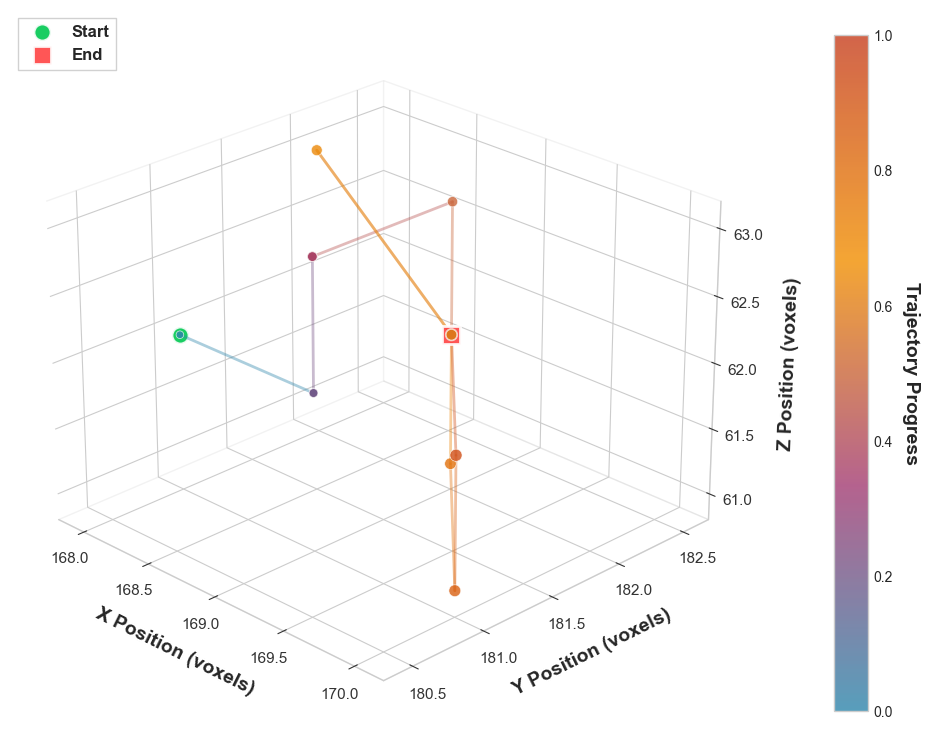

In [141]:
plot_track_3d_enhanced(track_df, ID, save_plot = False)  # Replace with the desired track_id

In [136]:
#import valid track intensity dataframe from /Volumes/ActiveNAS/Valerie/TransferFolder/20251204_DetectionTesting/lumenoids_analysis/datasets/valid_tracks_intensities.pkl
valid_tracks_intensities = pd.read_pickle('/Volumes/ActiveNAS/Valerie/TransferFolder/20251204_DetectionTesting/lumenoids_analysis/datasets/valid_tracks_intensities.pkl')
# Check what track 2746 looks like

In [142]:
#Confirm the channel2 and channel1 status of track == 'ID'

# Get the track data
track_data = track_df[track_df['track_id'] == ID]

if len(track_data) == 0:
    print(f"Track {ID} not found in track_df")
else:
    print(f"CHANNEL STATUS FOR TRACK {ID}")
    
    # Get channel status (assuming these columns exist)
    if 'channel2_positive' in track_data.columns:
        channel2_status = track_data['channel2_positive'].iloc[0]
        print(f"Channel 2 (DNM2) positive: {channel2_status}")
    else:
        print("'channel2_positive' column not found")
    
    if 'channel1_positive' in track_data.columns:
        channel1_status = track_data['channel1_positive'].iloc[0]
        print(f"Channel 1 (ArpC3) positive: {channel1_status}")
    else:
        print("'channel1_positive' column not found")
    



CHANNEL STATUS FOR TRACK 1982
Channel 2 (DNM2) positive: False
Channel 1 (ArpC3) positive: False


tracks_to_plot 1982


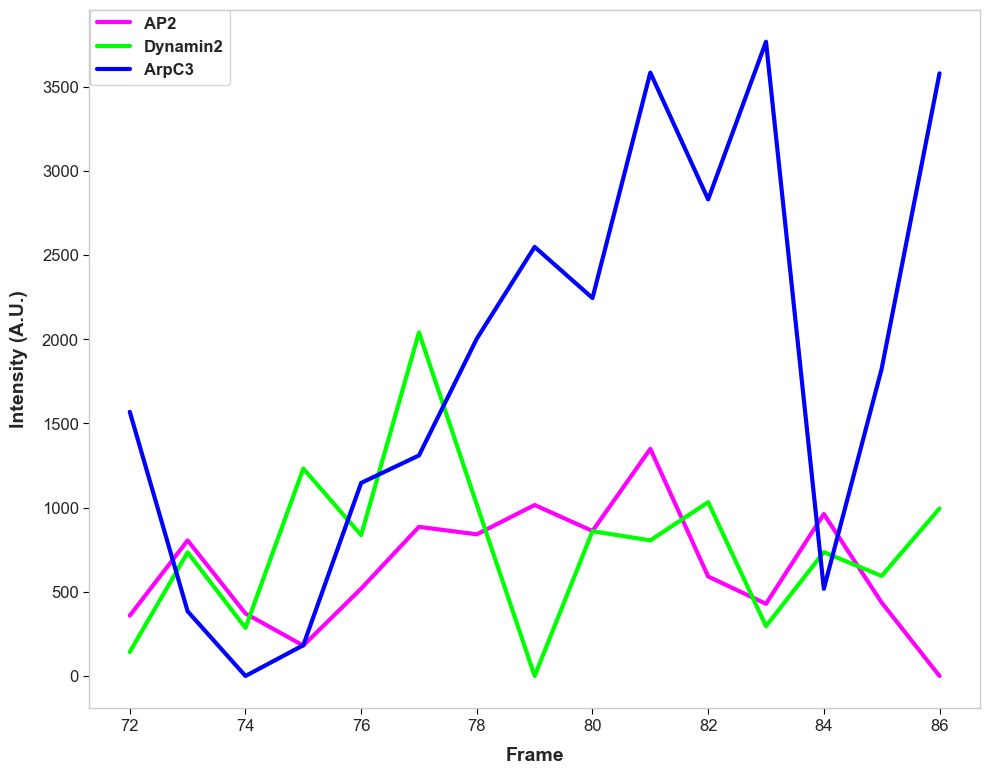

In [143]:
value_to_plot = 'voxel_sum_adjusted'
channel3_name = 'AP2'
channel2_name = 'Dynamin2'
channel1_name = 'ArpC3'

# set 'normalized = False' to plot raw intensities

intensity_time_plot_onetrack(dataframe = valid_tracks_intensities, tracks_to_plot = ID, 
intensity_to_plot = [f'c3_{value_to_plot}',f'c2_{value_to_plot}', f'c1_{value_to_plot}'], track_id_col_name = 'track_id', 
frame_col_name = 'frame', channels_to_plot = 3, legend_values = [channel3_name, channel2_name, channel1_name],
line_colors = ['magenta', 'lime', 'blue'], graph_title = f'{value_to_plot}', normalized=False, save_plot = False)

Time points for track 1982: [72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86]


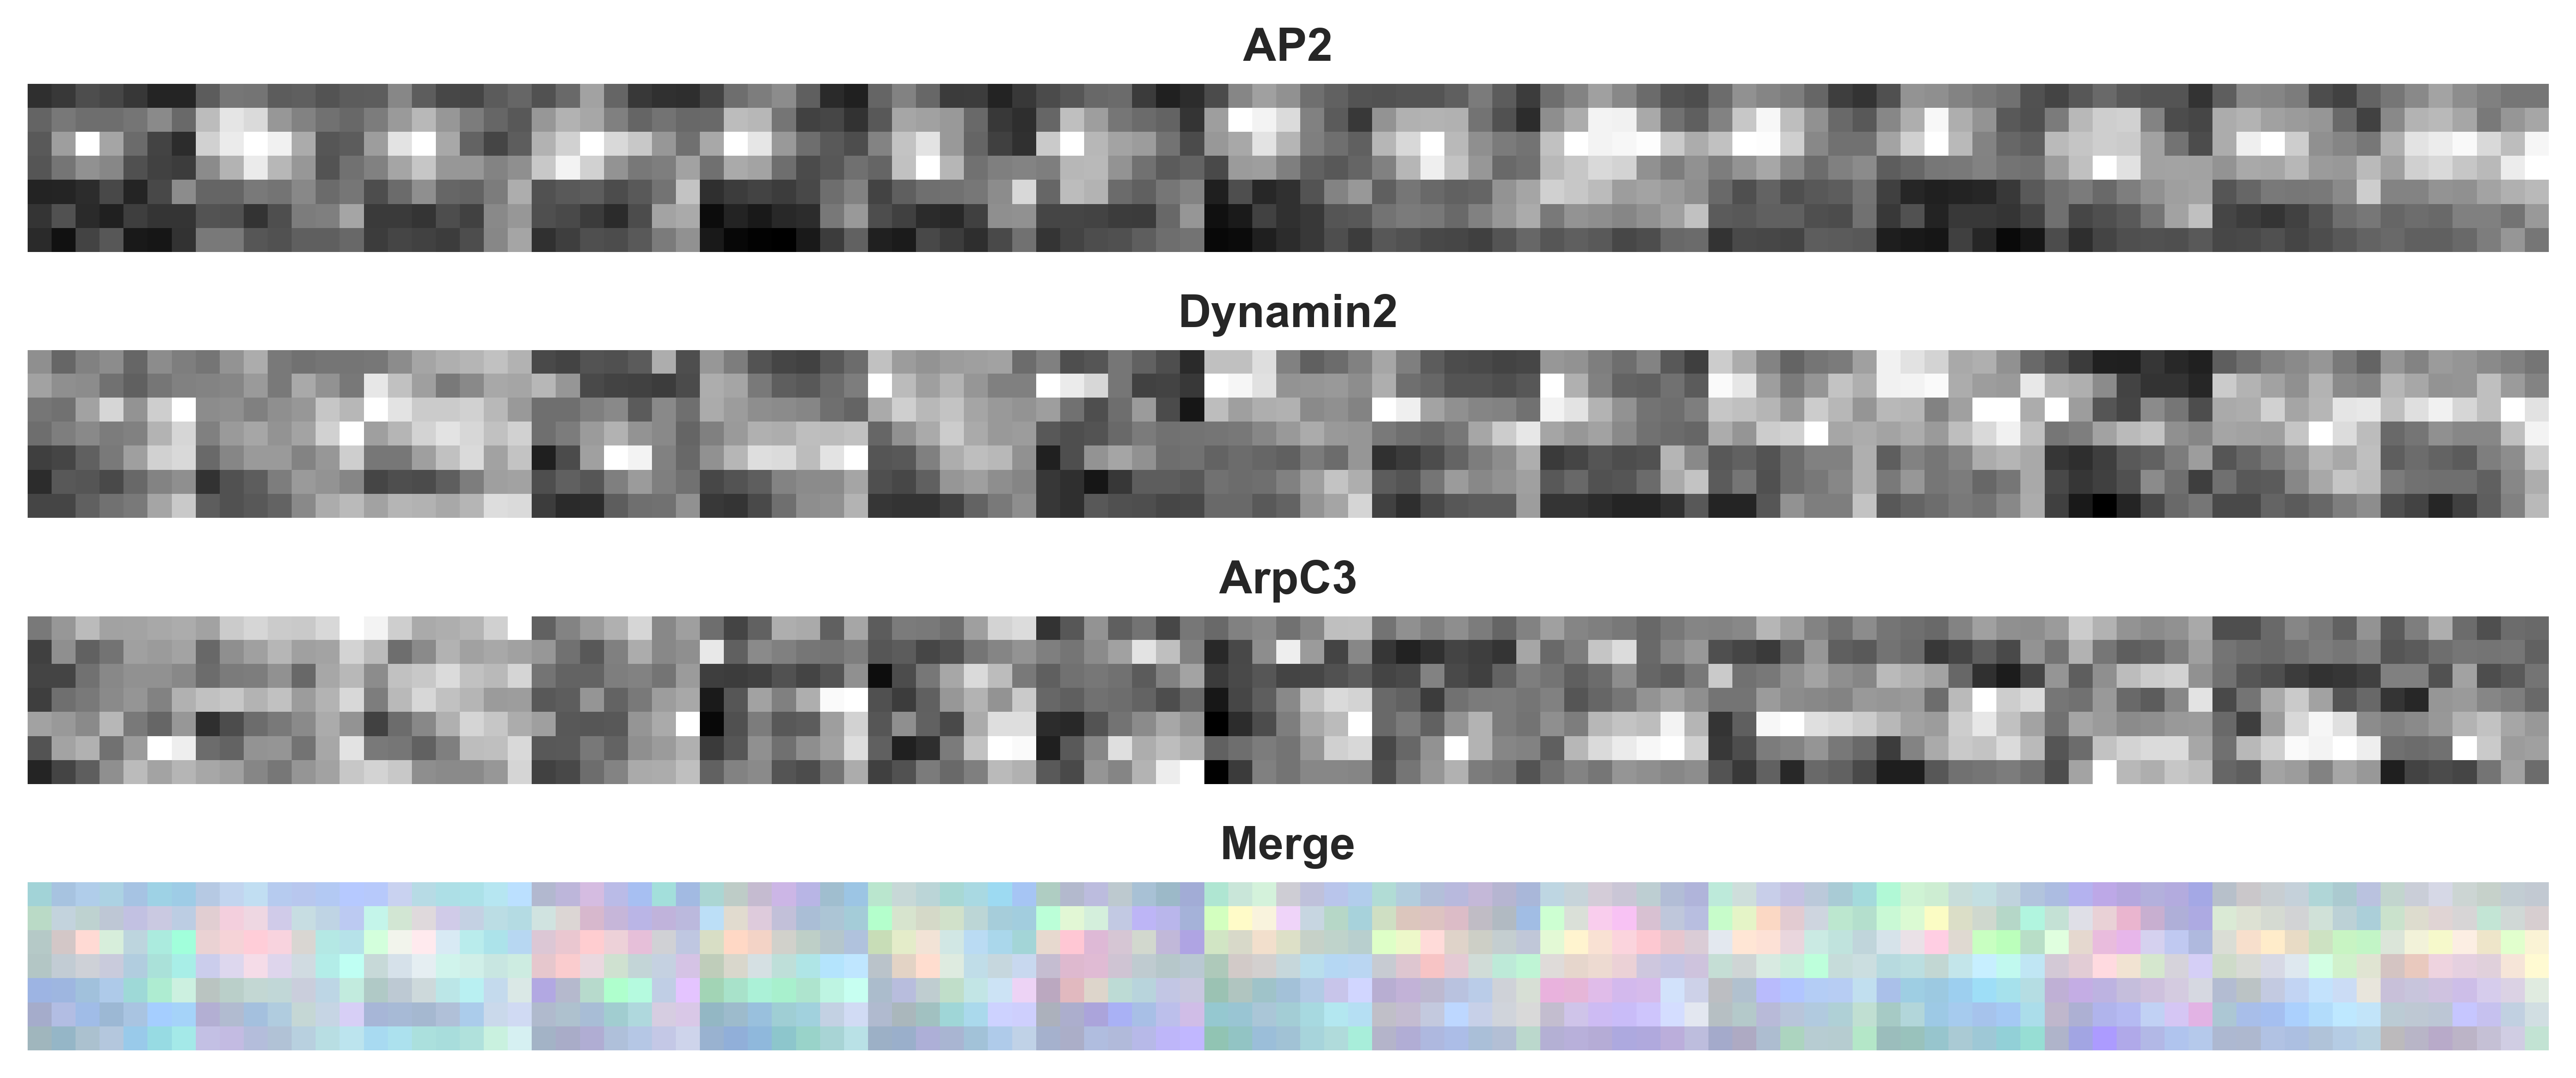

In [144]:
crop_size_z = 4
crop_size_xy = 3  # Half-width of the square patch

time = list(valid_tracks_intensities[valid_tracks_intensities['track_id'] == ID]['frame'])
print(f'Time points for track {ID}: {time}')
min_frame = min(time)
max_frame = max(time)

# Get coordinates per frame for this track
x_coord = track_df[track_df['track_id'] == ID]['mu_x'].values[0]
y_coord = track_df[track_df['track_id'] == ID]['mu_y'].values[0]
z_coord = track_df[track_df['track_id'] == ID]['mu_z'].values[0]

# Convert to integer coordinate tuples
coordinates_real = list(zip(x_coord, y_coord, z_coord))
coordinates_real = [tuple(int(val) for val in tup) for tup in coordinates_real]


# Prepare stacks for each channel
stack_arpc3, stack_dnm, stack_ap2, stack_merge = [], [], [], []

for t, (x, y, z) in zip(time, coordinates_real):
    # Extract patches (z, y, x) for all three channels, which includes a background strip
    arpc3_patch = z2[t, 0, (z-crop_size_z):(z+crop_size_z+1), (y-crop_size_xy):(y+crop_size_xy+1), (x-crop_size_xy):(x+crop_size_xy+1)]
    dnm_patch   = z2[t, 1, (z-crop_size_z):(z+crop_size_z+1), (y-crop_size_xy):(y+crop_size_xy+1), (x-crop_size_xy):(x+crop_size_xy+1)]
    ap2_patch   = z2[t, 2, (z-crop_size_z):(z+crop_size_z+1), (y-crop_size_xy):(y+crop_size_xy+1), (x-crop_size_xy):(x+crop_size_xy+1)]

    # Max intensity projection
    arpc3_proj = np.max(arpc3_patch, axis=0)
    dnm_proj   = np.max(dnm_patch, axis=0)
    ap2_proj   = np.max(ap2_patch, axis=0)

    # Normalize for display
    arpc3_norm = arpc3_proj / np.max(arpc3_proj) if np.max(arpc3_proj) > 0 else arpc3_proj
    dnm_norm   = dnm_proj   / np.max(dnm_proj)   if np.max(dnm_proj)   > 0 else dnm_proj
    ap2_norm   = ap2_proj   / np.max(ap2_proj)   if np.max(ap2_proj)   > 0 else ap2_proj

    # Add to individual grayscale channel strips
    stack_arpc3.append(arpc3_norm)
    stack_dnm.append(dnm_norm)
    stack_ap2.append(ap2_norm)

    # Merge: RFP (red), GFP (green), HALO (blue)
    rgb = np.stack([
        ap2_norm,    # Red: AP2-RFP
        dnm_norm,    # Green: DNM2-GFP
        arpc3_norm   # Blue: ARPC3-HALO
    ], axis=-1)
    stack_merge.append(rgb)

# Concatenate each channel across time
ap2_strip    = np.hstack(stack_ap2)
dnm_strip    = np.hstack(stack_dnm)
arpc3_strip  = np.hstack(stack_arpc3)
merge_strip  = np.hstack(stack_merge)

# Plot the 4 rows
fig, ax = plt.subplots(4, 1, figsize=(len(stack_ap2), 4), dpi=600)

ax[0].imshow(ap2_strip, cmap='gray')
ax[0].set_title('AP2', fontsize=12, fontweight='bold')

ax[1].imshow(dnm_strip, cmap='gray')
ax[1].set_title('Dynamin2', fontsize=12, fontweight='bold')

ax[2].imshow(arpc3_strip, cmap='gray')
ax[2].set_title('ArpC3', fontsize=12, fontweight='bold')

ax[3].imshow(merge_strip)
ax[3].set_title('Merge', fontsize=12, fontweight='bold')


# ax[0].imshow(rfp_strip, cmap='Reds')        # or 'magenta' 
# ax[0].set_title('AP2', color = 'red', fontsize = 12, fontweight='bold')
# ax[1].imshow(dnm_strip, cmap='Greens')       # or custom cyan
# ax[1].set_title('Dynamin2', color = 'green', fontsize = 12, fontweight='bold')
# ax[2].imshow(arpc3_strip, cmap='Blues')    # or custom yellow
# ax[2].set_title('ArpC3', color = 'blue', fontsize = 12, fontweight='bold')
# ax[3].imshow(merge_strip)  # Your RGB merge
# ax[3].set_title('Merge', color = 'black', fontsize = 12, fontweight='bold')

for a in ax:
    a.axis('off')

plt.tight_layout()

save_plot = False  # Set this to True if you want to save the plot
if save_plot:
    filename = f'kymograph_track_{ID}.png'
    plt.savefig(filename, dpi=600, bbox_inches='tight', facecolor='white')

plt.show()

In [148]:
ID = 2746

In [151]:
# Filter for the specific track ID
track_data = valid_tracks_intensities[valid_tracks_intensities['track_id'] == ID]

print(f"Track {ID} - Total frames: {len(track_data)}")
print("="*80)

# Show specific columns you're interested in
cols_to_show = ['track_id', 'frame', 'track_id', 'dnm2_positive','arpc3_positive',
                'dnm2_positive_track', 'arpc3_positive_track',]

display(track_data[cols_to_show])

Track 2746 - Total frames: 20


,track_id,frame,track_id,dnm2_positive,arpc3_positive,dnm2_positive_track,arpc3_positive_track
18392,2746,106,2746,False,False,True,True
18592,2746,107,2746,True,False,True,True
18859,2746,108,2746,False,False,True,True
19009,2746,109,2746,False,False,True,True
19232,2746,110,2746,True,False,True,True
19321,2746,111,2746,False,True,True,True
19648,2746,112,2746,False,False,True,True
19812,2746,113,2746,False,False,True,True
19963,2746,114,2746,False,False,True,True
20231,2746,115,2746,False,False,True,True


In [57]:
# Montages with a few (3) frames before and after the track's time points

crop_size_z = 4
crop_size_xy = 3  # Half-width of the square patch

time = list(track_df[track_df['track_id'] == ID]['frame'])
# Print max frames in the dataset
print(f'Max frames in the dataset: {max_frames}')
print(f'Time points for track {ID}: {time}')
# Extend time range by 3 frames before and after the track's time points
# This ensures we have a buffer around the track for visualization
extended_time = list(range(max(0, min(time) - 3), min((max_frames-1), max(time) + 3) + 1)) if time else []
# Drop values in extended_time that are between min(time) and max(time), but not in time. This takes care 
# of missing frames in the track.
extended_time = [frame for frame in extended_time if frame < min(time) or frame > max(time) or frame in time]
print(f'Extended time points for track {ID}: {extended_time}')

# Get coordinates per frame for this track
x_coord = filtered_tracks[filtered_tracks['track_id'] == ID]['mu_x'].values[0]
y_coord = filtered_tracks[filtered_tracks['track_id'] == ID]['mu_y'].values[0]
z_coord = filtered_tracks[filtered_tracks['track_id'] == ID]['mu_z'].values[0]

# Extend coordinates to match new time range
extended_x = []
extended_y = []
extended_z = []

min_frame = min(time)
max_frame = max(time)
for frame in extended_time:
    if frame < min_frame:
        # Use first coordinate for prior frames
        extended_x.append(x_coord.iloc[0])
        extended_y.append(y_coord.iloc[0])
        extended_z.append(z_coord.iloc[0])
    elif frame > max_frame:
        # Use last coordinate for future frames
        extended_x.append(x_coord.iloc[-1])
        extended_y.append(y_coord.iloc[-1])
        extended_z.append(z_coord.iloc[-1])
    else:
        # Use actual coordinate for existing frames, skip if not in time
        frame_idx = time.index(frame) # if frame in time else None
        # if frame_idx is None: #skip if frame is not in time
        #     continue
        extended_x.append(x_coord.iloc[frame_idx])
        extended_y.append(y_coord.iloc[frame_idx])
        extended_z.append(z_coord.iloc[frame_idx])

# Convert to integer coordinate tuples
coordinates = list(zip(x_coord, y_coord, z_coord))
print(f'Coordinates for track {ID}: {coordinates}')
coordinates_extended = list(zip(extended_x, extended_y, extended_z))
print(f'Extended coordinates for track {ID}: {coordinates_extended}')
coordinates_extended = [tuple(int(val) for val in tup) for tup in coordinates_extended]


# Prepare stacks for each channel
stack_ap2, stack_dnm, stack_arpc3, stack_merge = [], [], [], []

for t, (x, y, z) in zip(extended_time, coordinates_extended):
    print(f'Processing frame {t} with coordinates (x={x}, y={y}, z={z})')
    # Extract patches (z, y, x) for all three channels
    arpc3_patch = z2[t, 0, (z-crop_size_z):(z+crop_size_z+1), (y-crop_size_xy):(y+crop_size_xy+1), (x-crop_size_xy):(x+crop_size_xy+1)]
    dnm_patch   = z2[t, 1, (z-crop_size_z):(z+crop_size_z+1), (y-crop_size_xy):(y+crop_size_xy+1), (x-crop_size_xy):(x+crop_size_xy+1)]
    ap2_patch   = z2[t, 2, (z-crop_size_z):(z+crop_size_z+1), (y-crop_size_xy):(y+crop_size_xy+1), (x-crop_size_xy):(x+crop_size_xy+1)]

    # Max intensity projection
    arpc3_proj = np.max(arpc3_patch, axis=0)
    dnm_proj   = np.max(dnm_patch, axis=0)
    ap2_proj   = np.max(ap2_patch, axis=0)

    # Normalize for display
    arpc3_norm = arpc3_proj / np.max(arpc3_proj) if np.max(arpc3_proj) > 0 else arpc3_proj
    dnm_norm   = dnm_proj   / np.max(dnm_proj)   if np.max(dnm_proj)   > 0 else dnm_proj
    ap2_norm   = ap2_proj   / np.max(ap2_proj)   if np.max(ap2_proj)   > 0 else ap2_proj

    # Add to individual grayscale channel strips
    stack_arpc3.append(arpc3_norm)
    stack_dnm.append(dnm_norm)
    stack_ap2.append(ap2_norm)

    # # Add to individual grayscale channel strips
    # stack_arpc3.append(arpc3_proj)
    # stack_dnm.append(dnm_proj)
    # stack_rfp.append(rfp_proj)

    # Merge: RFP (red), GFP (green), HALO (blue)
    rgb = np.stack([
        ap2_norm,    # Red: AP2-RFP
        dnm_norm,    # Green: DNM2-GFP
        arpc3_norm   # Blue: ARPC3-HALO
    ], axis=-1)
    stack_merge.append(rgb)

    # # Merge: RFP (red), GFP (green), HALO (blue)
    # rgb = np.stack([
    #     rfp_proj,    # Red: AP2-RFP
    #     dnm_proj,    # Green: DNM2-GFP
    #     arpc3_proj   # Blue: ARPC3-HALO
    # ], axis=-1)
    # stack_merge.append(rgb)

# Concatenate each channel across time
ap2_strip    = np.hstack(stack_ap2)
dnm_strip    = np.hstack(stack_dnm)
arpc3_strip  = np.hstack(stack_arpc3)
merge_strip  = np.hstack(stack_merge)

# Adding arrow positions for the extended time range
arrow_positions = []
for i, frame in enumerate(extended_time):
    if frame not in time:  # Frame is extended, not original
        arrow_positions.append(i * (2*crop_size_xy + 1) + crop_size_xy)  # Center of each patch

# Plot the 4 rows
fig, ax = plt.subplots(4, 1, figsize=(len(stack_ap2), 4), dpi=600)

strips = [ap2_strip, dnm_strip, arpc3_strip, merge_strip]
titles = ['AP2', 'Dynamin2', 'ArpC3', 'Merge']
cmaps = ['gray', 'gray', 'gray', None]

for i, (strip, title, cmap) in enumerate(zip(strips, titles, cmaps)):
   ax[i].imshow(strip, cmap=cmap)
   for pos in arrow_positions:
       ax[i].annotate('', xy=(pos, -0.5), xytext=(pos, 0), 
                      arrowprops=dict(arrowstyle='-|>', color='red', lw=2))
   ax[i].set_title(title, fontsize=12, fontweight='bold')

for a in ax:
    a.axis('off')

plt.tight_layout()

save_plot = False  # Set this to True if you want to save the plot
if save_plot:
    filename = f'kymograph_track_{ID}.png'
    plt.savefig(filename, dpi=600, bbox_inches='tight', facecolor='white')

plt.show()


KeyError: 'frame'